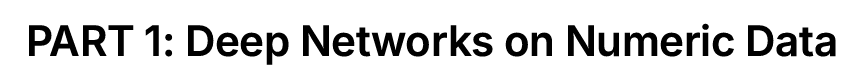

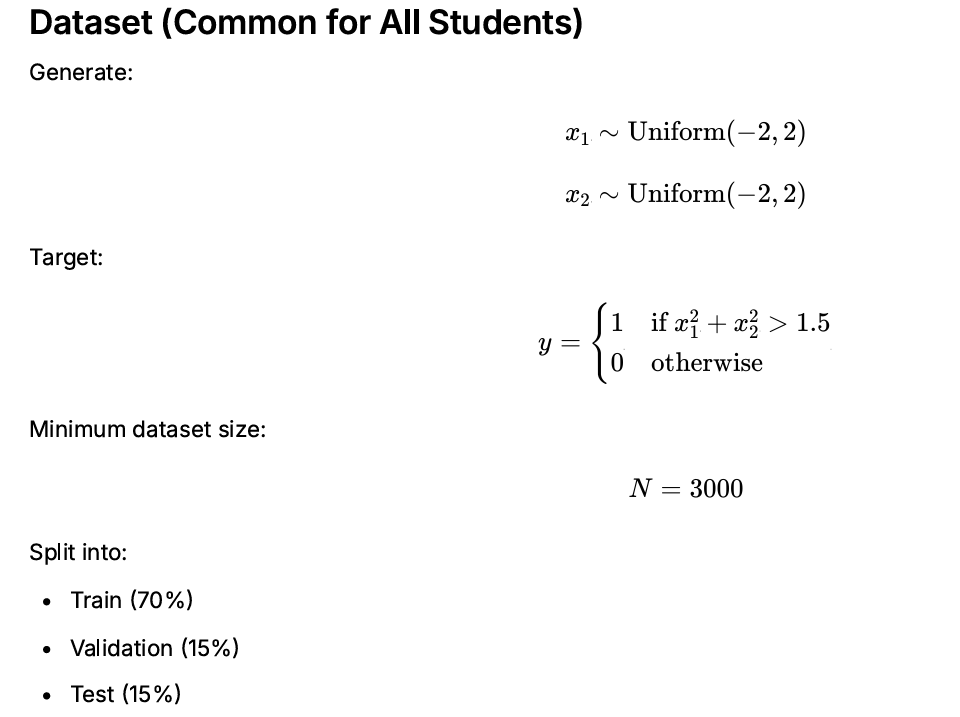

In [1]:
#Dataset Generation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
N = 3000
x1 = np.random.uniform (-2, 2, N)
x2 = np.random.uniform (-2, 2, N)

X = np.column_stack((x1, x2))

y = np.where(x1**2 + x2**2 > 1.5,1,0)
y = y.reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 2)
y shape: (3000, 1)


In [2]:
#Train/Validate/Test Split (70/15/15)
indices = np.random.permutation(N)
X,y = X[indices], y[indices]

train_end = int(0.7*N)
val_end = train_end + int(0.15*N)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end : val_end], y[train_end : val_end]
X_test , y_test = X[val_end:], y[val_end:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2100, 2)
(450, 2)
(450, 2)


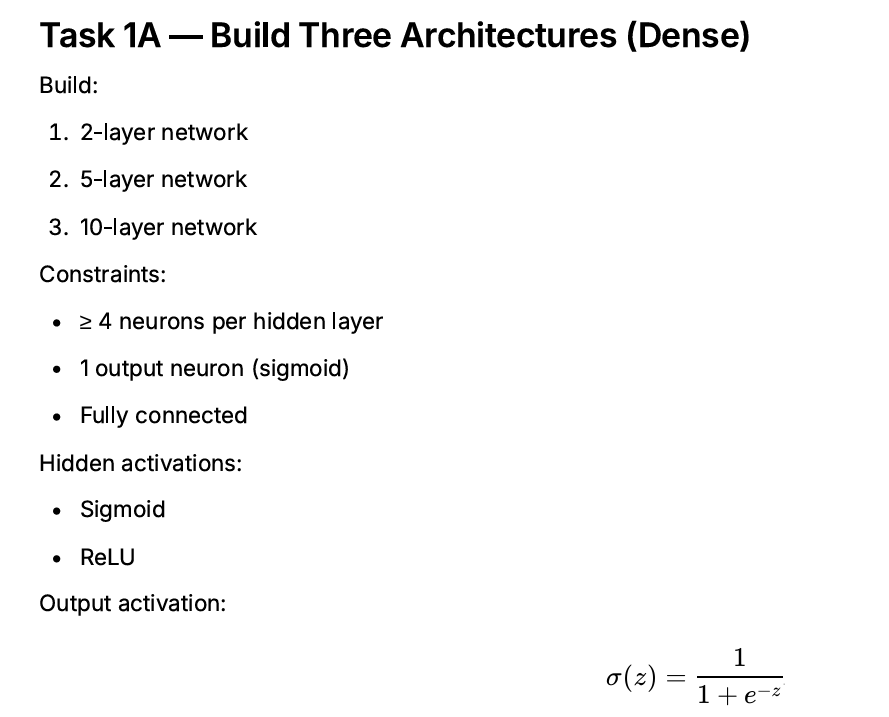

In [3]:
#Activation Functions
def sigmoid(z):
  return 1/(1+np.exp(-z))

def sigmoid_derivative(z):
  s = sigmoid(z)
  return s*(1-s)

def relu(z):
  return np.maximum(0,z)

def relu_derivative(z):
  return (z>0).astype(float)

In [4]:
#Loss
def bce_loss(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )
    return loss

In [5]:
#Accuracy
def accuracy(y, y_hat):
    preds = (y_hat >= 0.5).astype(int)
    return np.mean(preds == y)

In [6]:
#Initialization
def initialize_network(layers):
  params = {}
  for i in range(len(layers) - 1):
       params["W" + str(i+1)] = np.random.randn(
            layers[i], layers[i+1]
        ) * 0.01
       params["b" + str(i+1)] = np.zeros(
            (1, layers[i+1])
        )
  return params

In [7]:
params = initialize_network([2,8,1])
print(params.keys())

dict_keys(['W1', 'b1', 'W2', 'b2'])


In [8]:
#Forward Pass
def forward(X, params, activation="relu"):
    cache = {}
    A = X
    L = len(params)//2
    for l in range(1, L):
        Z = np.dot(A, params["W"+str(l)]) + params["b"+str(l)]
        if activation == "relu":
            A = relu(Z)
        else:
            A = sigmoid(Z)

        cache["A"+str(l)] = A
        cache["Z"+str(l)] = Z

    # output layer
    Z = np.dot(A, params["W"+str(L)]) + params["b"+str(L)]
    A = sigmoid(Z)
    cache["A"+str(L)] = A
    cache["Z"+str(L)] = Z

    return A, cache

In [9]:
#Backward Propogation
def backward(X, y, params, cache, activation="relu"):
    grads = {}
    L = len(params)//2
    m = X.shape[0]
    A_final = cache["A"+str(L)]
    dZ = A_final - y

    for l in reversed(range(1, L+1)):
        A_prev = X if l==1 else cache["A"+str(l-1)]
        grads["dW"+str(l)] = np.dot(A_prev.T, dZ)/m
        grads["db"+str(l)] = np.sum(dZ,axis=0,keepdims=True)/m

        if l > 1:
            dA = np.dot(dZ, params["W"+str(l)].T)
            if activation == "relu":
                dZ = dA * relu_derivative(cache["Z"+str(l-1)])
            else:
                dZ = dA * sigmoid_derivative(cache["A"+str(l-1)])

    return grads

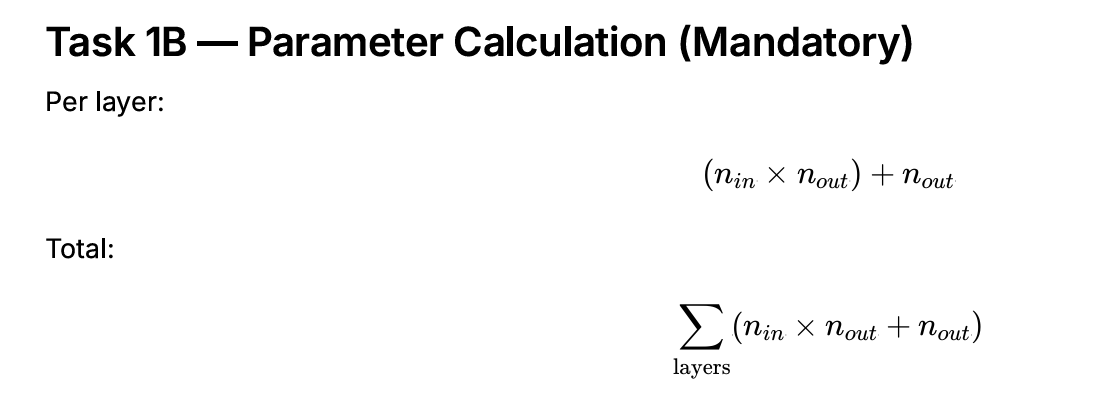

**2 Layer Network**

Layer 1 = Input to Hidden
      
      (2x8) + 8 = 24

Layer 2 = Hidden to Output

     (8x1) + 1 = 9

**TOTAL** = 24+9 = 33





---


**5 Layer Network**

Layer 1 = Input to Hidden1
           
      (2x8) + 8 = 24

Layer 2 = Hidden1 to Hidden2
     
      (8x8) + 8 = 72

As there are 3 hidden layers

Therefore, Layer 2 to 3 = Hidden1 to Hidden4

     3x72 = 216

Layer 3 = Hidden4 to Output
    
     (8x1) + 1 = 9
    
**TOTAL** = 24+216+9 = 249



---




**10 Layer Network**
Layer 1 = Input to Hidden1
           
      (2x8) + 8 = 24

Layer 2 = Hidden1 to Hidden2
     
      (8x8) + 8 = 72

As there are 8 hidden layers

Therefore, Layer 2 to 9 = Hidden1 to Hidden9

     8x72 = 576

Layer 3 = Hidden9 to Output
    
     (8x1) + 1 = 9

**TOTAL** = 24+576+9 = 609



---


**Number of Parameters:**

**2 Layer = 33**

**5 Layer = 249**

**10 Layer = 609**







In [10]:
def count_params(layers):
    total=0
    for i in range(len(layers)-1):
        total+=layers[i]*layers[i+1]+layers[i+1]
    return total

params_2=count_params([2,8,1])
params_5=count_params([2,8,8,8,8,1])
params_10=count_params([2,8,8,8,8,8,8,8,8,8,1])

print(params_2,params_5,params_10)

33 249 609


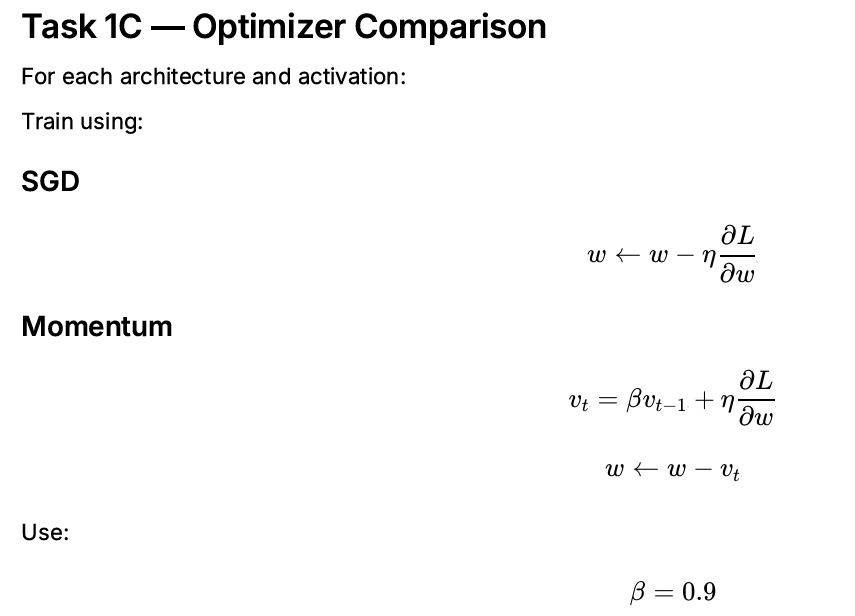

In [11]:
#Optimizers
def update_sgd(params,grads,lr):
    L=len(params)//2
    for l in range(1,L+1):
        params["W"+str(l)]-=lr*grads["dW"+str(l)]
        params["b"+str(l)]-=lr*grads["db"+str(l)]

    return params

def update_momentum(params,grads,velocity,lr,beta=0.9):
    L=len(params)//2
    for l in range(1,L+1):
        velocity["W"+str(l)]=beta*velocity["W"+str(l)] + lr*grads["dW"+str(l)]
        velocity["b"+str(l)]=beta*velocity["b"+str(l)] + lr*grads["db"+str(l)]
        params["W"+str(l)]-=velocity["W"+str(l)]
        params["b"+str(l)]-=velocity["b"+str(l)]

    return params,velocity

In [12]:
def initialize_velocity(params):
    velocity={}
    L=len(params)//2
    for l in range(1,L+1):
        velocity["W"+str(l)]=np.zeros_like(params["W"+str(l)])
        velocity["b"+str(l)]=np.zeros_like(params["b"+str(l)])
    return velocity

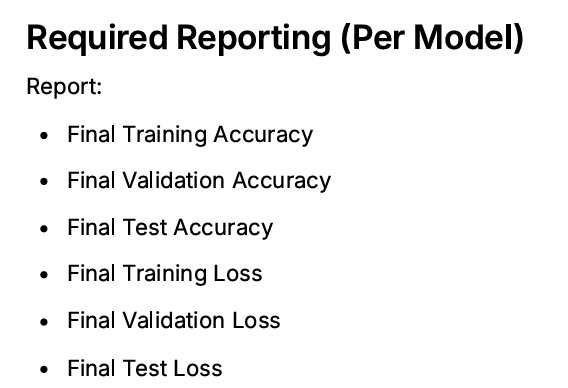

In [13]:
def train_model(X_train,y_train,X_val,y_val,
                layers,activation,optimizer,
                lr=0.01,epochs=200):

    params = initialize_network(layers)
    # initialize lists
    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    # momentum velocity
    if optimizer == "momentum":
        velocity = initialize_velocity(params)

    for epoch in range(epochs):
        # forward
        y_pred,cache = forward(X_train,params,activation)
        # compute gradients
        grads = backward(X_train,y_train,params,cache,activation)
        # update weights
        if optimizer == "sgd":
            params = update_sgd(params,grads,lr)
        else:
            params,velocity = update_momentum(params,grads,velocity,lr)
        # validation prediction
        val_pred,_ = forward(X_val,params,activation)
        # compute losses
        train_loss.append(bce_loss(y_train,y_pred))
        val_loss.append(bce_loss(y_val,val_pred))
        # compute accuracy
        train_acc.append(accuracy(y_train,y_pred))
        val_acc.append(accuracy(y_val,val_pred))

    return params,train_loss,val_loss,train_acc,val_acc

In [14]:
architectures = {
    "2-layer":[2,8,1],
    "5-layer":[2,8,8,8,8,1],
    "10-layer":[2,8,8,8,8,8,8,8,8,8,1]
}
activations = ["sigmoid","relu"]
optimizers = ["sgd","momentum"]

In [15]:
results1 = []
for arch_name,layers in architectures.items():
  for act in activations:
    for opt in optimizers:
      print("\nTraining:",arch_name,act,opt)
      params,train_loss,val_loss,train_acc,val_acc = train_model(
                X_train,
                y_train,
                X_val,
                y_val,
                layers,
                act,
                opt,
                lr=0.01,
                epochs=200
            )

      # Test evaluation
      test_pred,_ = forward(X_test,params,act)
      test_acc = accuracy(y_test,test_pred)
      test_loss = bce_loss(y_test,test_pred)
      results1.append({
                "Model":arch_name,
                "Activation":act,
                "Optimizer":opt,
                "Train Acc":train_acc[-1],
                "Val Acc":val_acc[-1],
                "Test Acc":test_acc,
                "Train Loss":train_loss[-1],
                "Val Loss":val_loss[-1],
                "Test Loss":test_loss
            })

print("Train Acc:",train_acc[-1])
print("Val Acc:",val_acc[-1])
print("Test Acc:",test_acc)


Training: 2-layer sigmoid sgd

Training: 2-layer sigmoid momentum

Training: 2-layer relu sgd

Training: 2-layer relu momentum

Training: 5-layer sigmoid sgd

Training: 5-layer sigmoid momentum

Training: 5-layer relu sgd

Training: 5-layer relu momentum

Training: 10-layer sigmoid sgd

Training: 10-layer sigmoid momentum

Training: 10-layer relu sgd

Training: 10-layer relu momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74


In [16]:
import pandas as pd
results_df = pd.DataFrame(results1)
results_df

,Model,Activation,Optimizer,Train Acc,Val Acc,Test Acc,Train Loss,Val Loss,Test Loss
0,2-layer,sigmoid,sgd,0.704286,0.748889,0.74,0.612455,0.583513,0.589240
1,2-layer,sigmoid,momentum,0.704286,0.748889,0.74,0.607190,0.568487,0.576200
2,2-layer,relu,sgd,0.704286,0.748889,0.74,0.640394,0.625864,0.628729
3,2-layer,relu,momentum,0.704286,0.748889,0.74,0.605986,0.567285,0.575051
4,5-layer,sigmoid,sgd,0.704286,0.748889,0.74,0.612436,0.583465,0.589225
5,5-layer,sigmoid,momentum,0.704286,0.748889,0.74,0.607189,0.568484,0.576198
6,5-layer,relu,sgd,0.704286,0.748889,0.74,0.640376,0.625840,0.628706
7,5-layer,relu,momentum,0.704286,0.748889,0.74,0.607190,0.568636,0.576319
8,10-layer,sigmoid,sgd,0.704286,0.748889,0.74,0.612483,0.583555,0.589306
9,10-layer,sigmoid,momentum,0.704286,0.748889,0.74,0.607189,0.568484,0.576198


In [17]:
def plot_loss(train_loss, val_loss, title):
    plt.figure()
    plt.plot(train_loss, label="Training Loss")
    plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)

    plt.legend()
    plt.show()

In [18]:
def plot_accuracy(train_acc, val_acc, title):
    plt.figure()
    plt.plot(train_acc, label="Training Accuracy")
    plt.plot(val_acc, label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)

    plt.legend()
    plt.show()


Training: 2-layer sigmoid sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74

Training: 2-layer sigmoid momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74


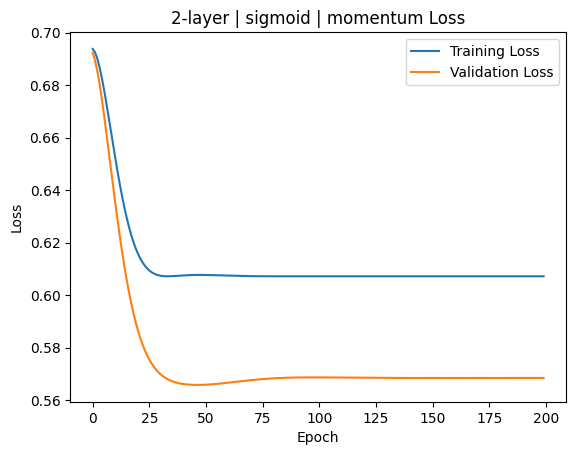

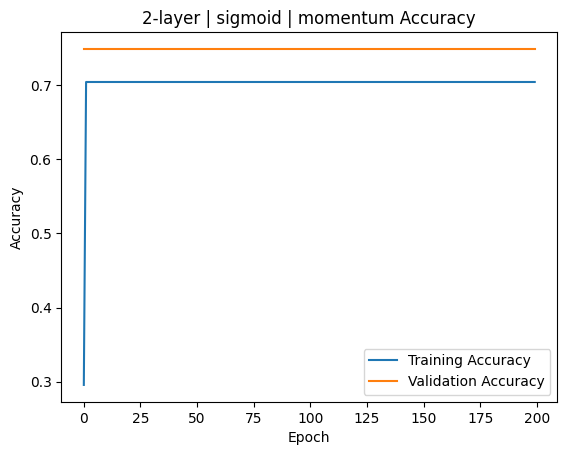


Training: 2-layer relu sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74

Training: 2-layer relu momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74


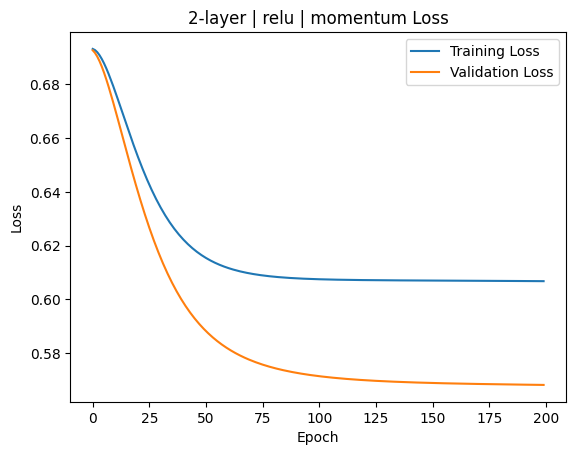

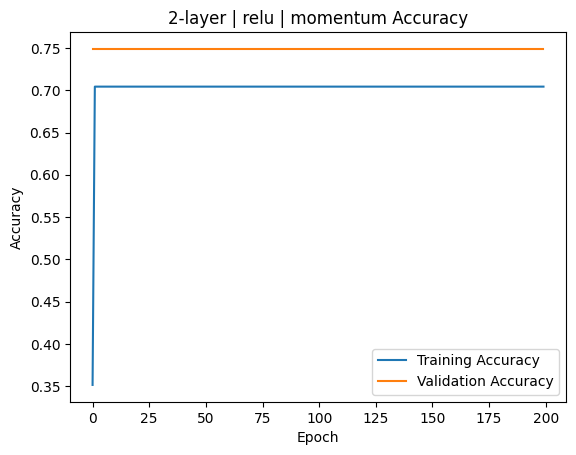


Training: 5-layer sigmoid sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74

Training: 5-layer sigmoid momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74


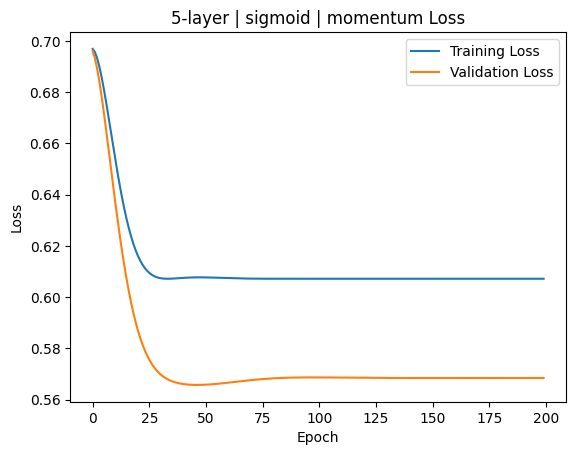

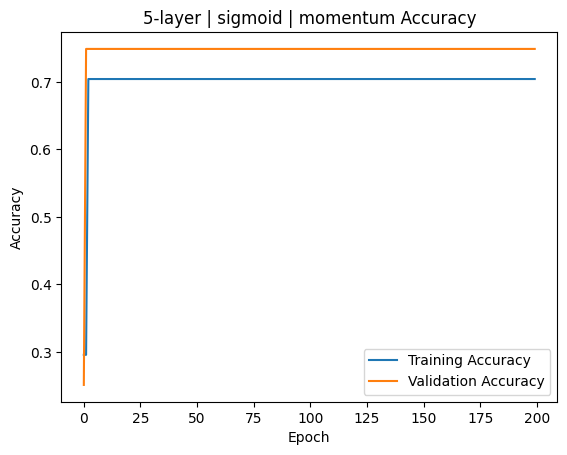


Training: 5-layer relu sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74

Training: 5-layer relu momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74


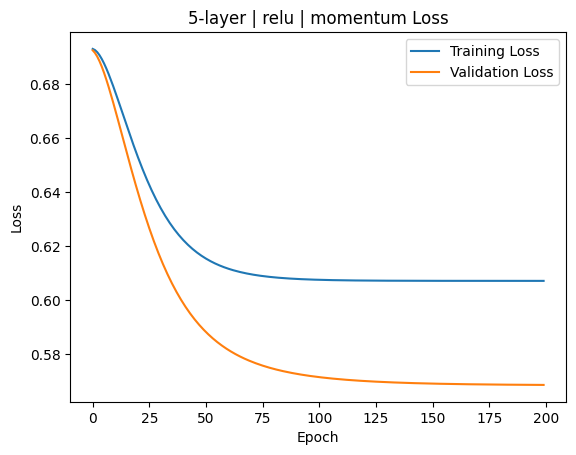

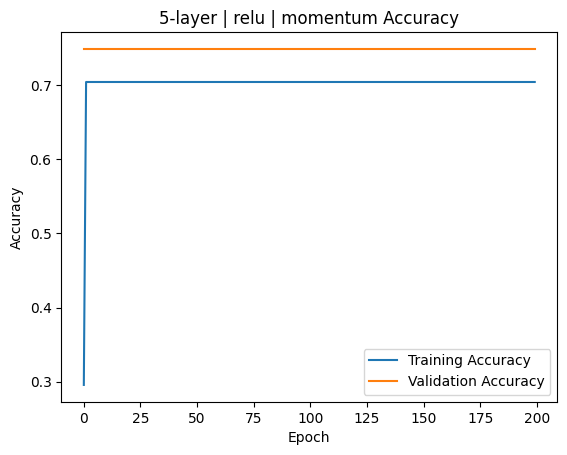


Training: 10-layer sigmoid sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74

Training: 10-layer sigmoid momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74


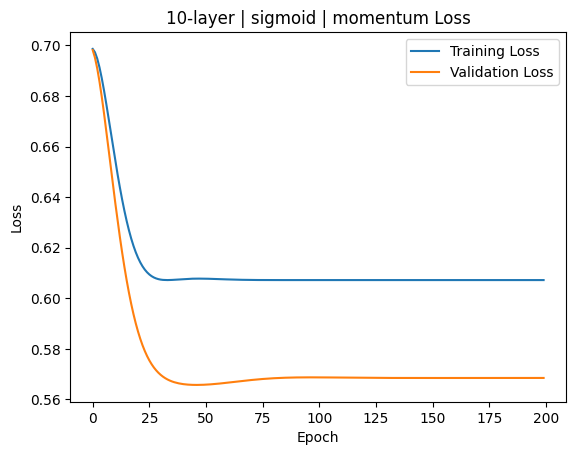

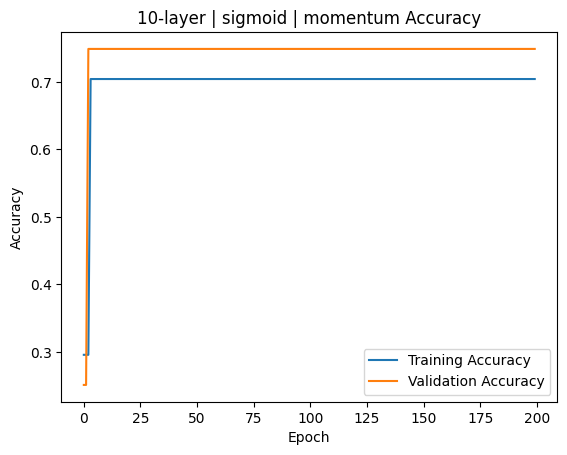


Training: 10-layer relu sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74

Training: 10-layer relu momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74


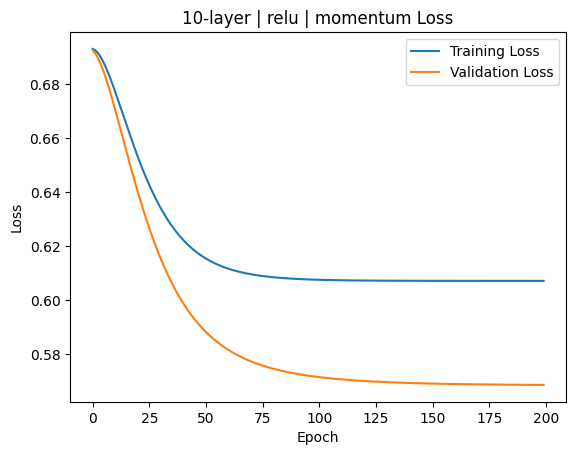

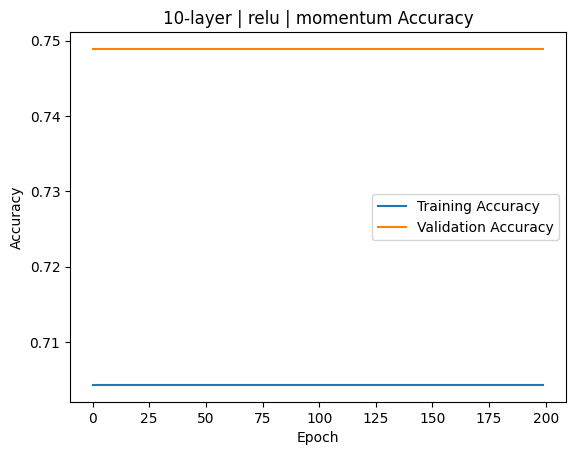

In [19]:
for arch_name, layers in architectures.items():
  for act in activations:
    for opt in optimizers:
      print("\nTraining:", arch_name, act, opt)
      params,train_loss,val_loss,train_acc,val_acc = train_model(
                X_train,
                y_train,
                X_val,
                y_val,
                layers,
                act,
                opt,
                lr=0.01,
                epochs=200
            )

      # Evaluate on test set
      test_pred,_ = forward(X_test,params,act)
      test_acc = accuracy(y_test,test_pred)
      test_loss = bce_loss(y_test,test_pred)
      print("Train Acc:",train_acc[-1])
      print("Val Acc:",val_acc[-1])
      print("Test Acc:",test_acc)

    # Plot curves
    plot_loss(train_loss,val_loss, f"{arch_name} | {act} | {opt} Loss")
    plot_accuracy(train_acc,val_acc, f"{arch_name} | {act} | {opt} Accuracy")

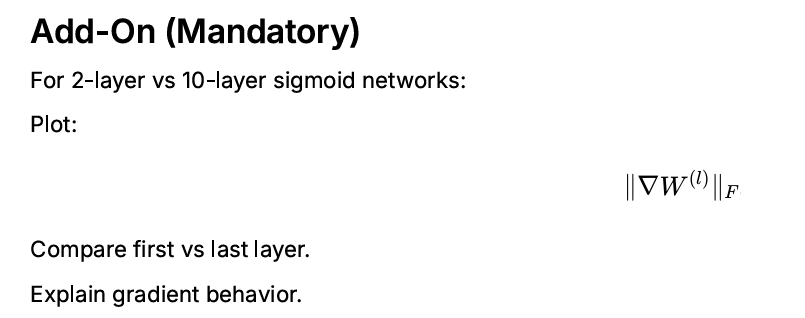

In [20]:
def gradient_norm(matrix):
    return np.sqrt(np.sum(matrix**2))

In [21]:
# Gradient Norm Function
def train_with_gradients(X_train, y_train, layers, epochs=200):
    params = initialize_network(layers)
    first_layer_grad = []
    last_layer_grad = []
    for epoch in range(epochs):
        # forward pass
        y_pred, cache = forward(X_train, params, "sigmoid")

        # backward pass
        grads = backward(X_train, y_train, params, cache, "sigmoid")

        # update weights
        params = update_sgd(params, grads, 0.01)

        L = len(params) // 2

        # first layer gradient
        first_layer_grad.append(
            gradient_norm(grads["dW1"])
        )

        # last layer gradient
        last_layer_grad.append(
            gradient_norm(grads["dW" + str(L)])
        )

    return first_layer_grad, last_layer_grad

In [22]:
#2 layer sigmoid
grad2_first, grad2_last = train_with_gradients(
    X_train, y_train, [2,8,1]
)

In [23]:
#10 layer sigmoid
grad10_first, grad10_last = train_with_gradients(
    X_train, y_train, [2,8,8,8,8,8,8,8,8,8,1]
)

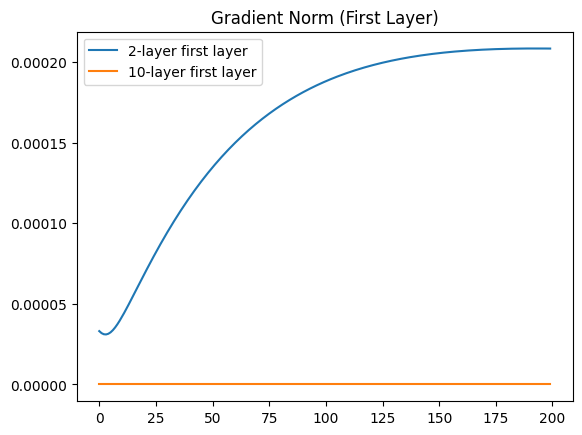

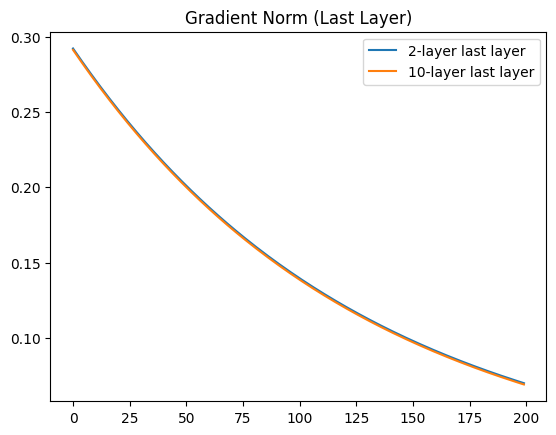

In [24]:
#Plot
plt.figure()
plt.plot(grad2_first, label="2-layer first layer")
plt.plot(grad10_first, label="10-layer first layer")
plt.title("Gradient Norm (First Layer)")
plt.legend()
plt.show()

plt.figure()
plt.plot(grad2_last, label="2-layer last layer")
plt.plot(grad10_last, label="10-layer last layer")
plt.title("Gradient Norm (Last Layer)")
plt.legend()
plt.show()

From the plots, we observe that in the 10-layer sigmoid network, the first-layer gradient norm is approximately zero throughout training, while the last-layer gradient norm remains significant.

This demonstrates the vanishing gradient problem. During backpropagation, gradients are multiplied by sigmoid derivatives at each layer. Since:

𝜎
′
(
𝑧
)
≤
0.25


Repeated multiplication across 9 hidden layers causes exponential shrinkage of the gradient magnitude.

As a result:

Early layers receive almost no gradient signal.

Learning becomes extremely slow in those layers.

Deep sigmoid networks degrade in performance.

In contrast, the 2-layer network does not suffer from this issue because the gradient passes through only one hidden layer.

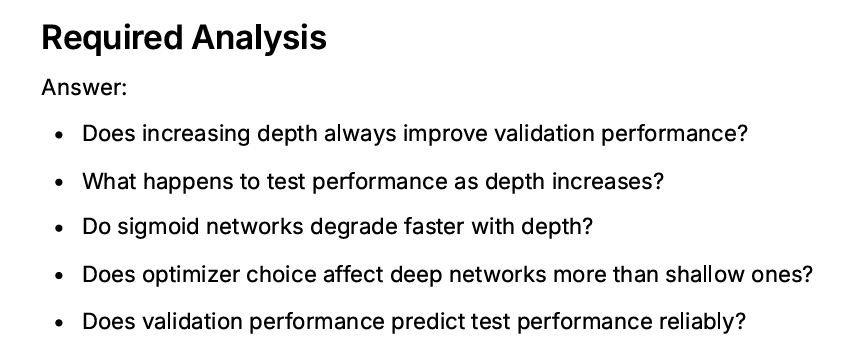

**1. Does increasing depth always improve validation performace?**

No. Increasing depth increases models capacity, which allows the network to learn more complex patterns. However, deeper networks are harder to optimize due to vanishing gradient and increased parameter count.

**2. What happens to test performance as depth increases? **

Test performance may initially improve as depth increases due to increased representational power. However, beyond a certain depth , performance may degrade due to

*  Vanishing Gradient(sigmoid)
*  Overfitting and Optimization Instability

Thus, deeper is not always better.

**3. Do Sigmoid network degrade faster with depth?**

Yes.Sigmoid networks degrade faster because:

𝜎
′
(
𝑧
)
≤
0.25


Repeated multiplication of small derivatives across many layers causes exponential shrinkage of gradients. This leads to slow learning in early layers and poor optimization in deep sigmoid networks.


**4. Does optimizer choice affect deep networks more than shallow ones?**

Yes.

Shallow networks generally train well even with basic SGD. However, deep networks benefit significantly from optimizers like Momentum.

Momentum:

Smooths gradient updates

Reduces oscillations

Helps propagate gradient information across layers

Thus, optimizer choice becomes more critical as depth increases.


**5. Does validation performance predict test performance reliably?**

In most cases, yes.

Validation performance is typically a good indicator of test performance if:

Data distribution is consistent

No severe overfitting occurs

However, small deviations may occur due to randomness in data splits or mild overfitting.



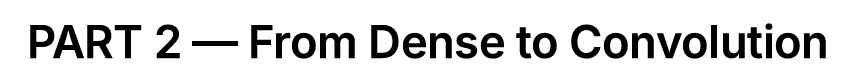

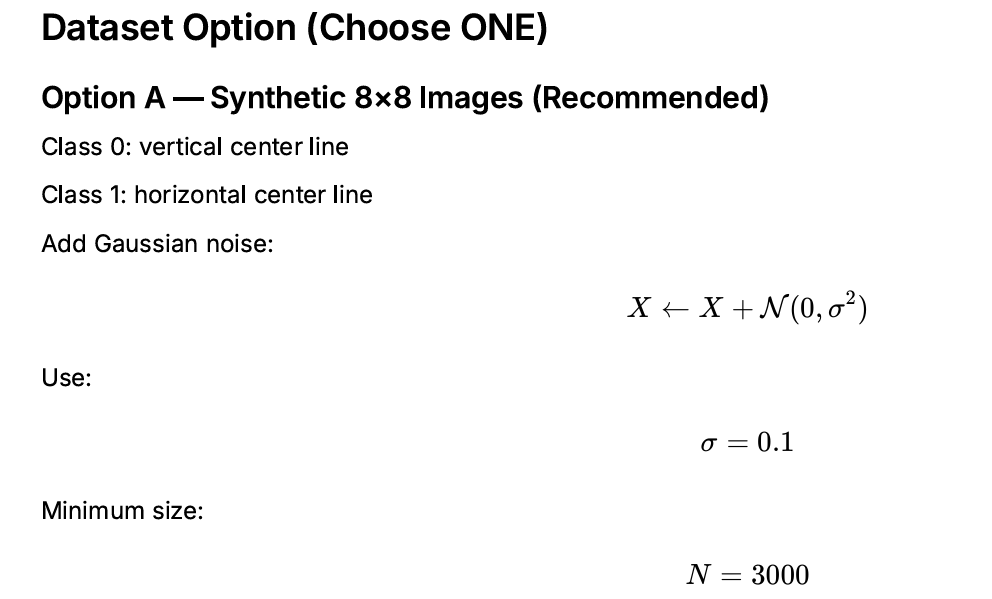

In [25]:
import numpy as np
np.random.seed(42)

def generate_images(N=3000,sigma=0.1):
  X = np.zeros((N,8,8))
  y = np.zeros(N)
  for i in range(N):
    if np.random.rand() < 0.5:
      #Class0 Vertical Center line
      X[i,:,4] = 1
      y[i] = 0
    else:
    #Class1 Horizontal Center line
     X[i,4,:] = 1
     y[i] = 1

    #Gaussian Noise
    X[i] += np.random.normal(0,sigma,(8,8))
  y = y.reshape(-1,1)
  return X,y

# Generate dataset (N >= 3000)
N = 3000
X, y = generate_images(N=N, sigma=0.1)

print("Image shape:", X.shape)
print("Label shape:", y.shape)

Image shape: (3000, 8, 8)
Label shape: (3000, 1)


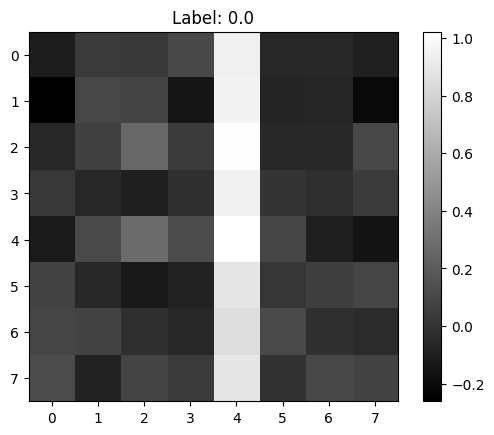

In [26]:
plt.imshow(X[0], cmap='gray')
plt.title(f"Label: {y[0][0]}")
plt.colorbar()
plt.show()

In [27]:
idx = np.random.permutation(N)
X = X[idx]
y = y[idx]

#Split
train_end = int(0.7*N)
val_end = int(0.85*N)
X_train = X[:train_end]
y_train = y[:train_end]
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

/tmp/ipykernel_42429/352014120.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(y_train[i])}")


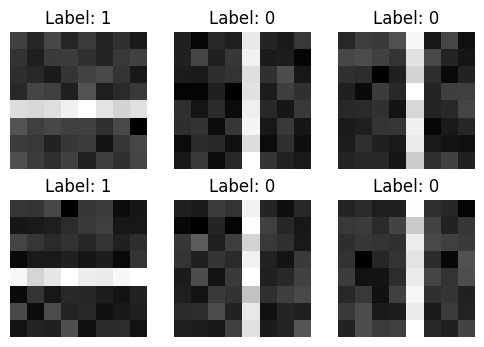

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {int(y_train[i])}")
    plt.axis('off')

plt.show()

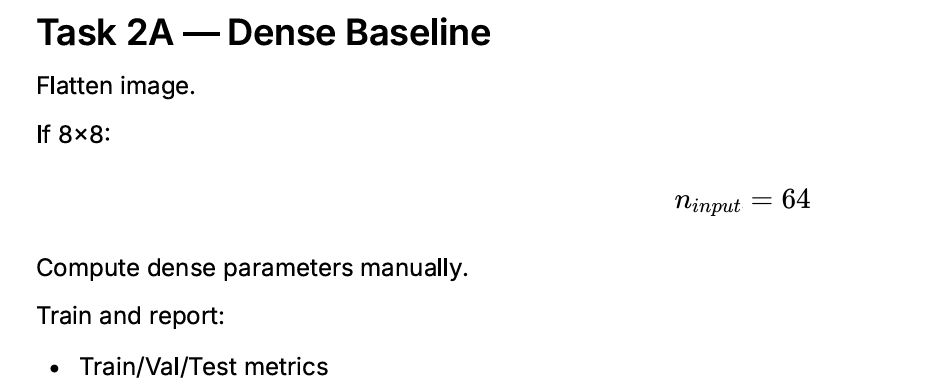

**Dense Paramenters**

8x8 Grayscale image = 8x8 = 64 pixels

Inputs = 64

**Baseline Architecture**= 64 -> 16 -> 1

Input layer -> 64 neurons

Hidden layer -> 16 neurons

Output layer  -> 1 neuron (sigmoid for binary classification)

Layer 1 = Input to Hidden (64->16)

weights = 64x16 = 1024

biases = 16 (each hidden neuron has 1 bias)

           
      (64x16) + 16 = 1040



Layer 2 = Hidden to Output (16->1)

weights = 16x1

biases = 1 (output)
    
     (16x1) + 1 = 17

**TOTAL** = 1040=17 = 1057

**Total Dense Baseline Parameters = 1057**



In [29]:
#Flatten
def flatten(X):
  return X.reshape(X.shape[0],-1)

X_train_flat = flatten(X_train)
X_val_flat = flatten(X_val)
X_test_flat = flatten(X_test)

In [30]:
y_train = y_train.reshape(-1,1)
y_val   = y_val.reshape(-1,1)
y_test  = y_test.reshape(-1,1)

In [31]:
print(X_train_flat.shape)
print(y_train.shape)

(2100, 64)
(2100, 1)


In [32]:
params = initialize_network([64,32,1])
print(params["W1"].shape)

(64, 32)


In [33]:
def train_dense_model(layers, activation="relu", optimizer="sgd", epochs=200, lr=0.01):
    params = initialize_network(layers)
    for epoch in range(epochs):
        # forward pass
        y_pred, cache = forward(X_train_flat, params, activation)

        # backward pass
        grads = backward(X_train_flat, y_train, params, cache, activation)

        # update weights
        params = update_sgd(params, grads, lr)

    # predictions
    train_pred,_ = forward(X_train_flat, params, "relu")
    val_pred,_ = forward(X_val_flat, params, "relu")
    test_pred,_ = forward(X_test_flat, params, "relu")

    return {
        "Train Acc": accuracy(y_train, train_pred),
        "Val Acc": accuracy(y_val, val_pred),
        "Test Acc": accuracy(y_test, test_pred)
    }

In [34]:
dense_layers = [64,32,1]
results = train_dense_model(dense_layers)
print(results)

{'Train Acc': np.float64(1.0), 'Val Acc': np.float64(1.0), 'Test Acc': np.float64(1.0)}


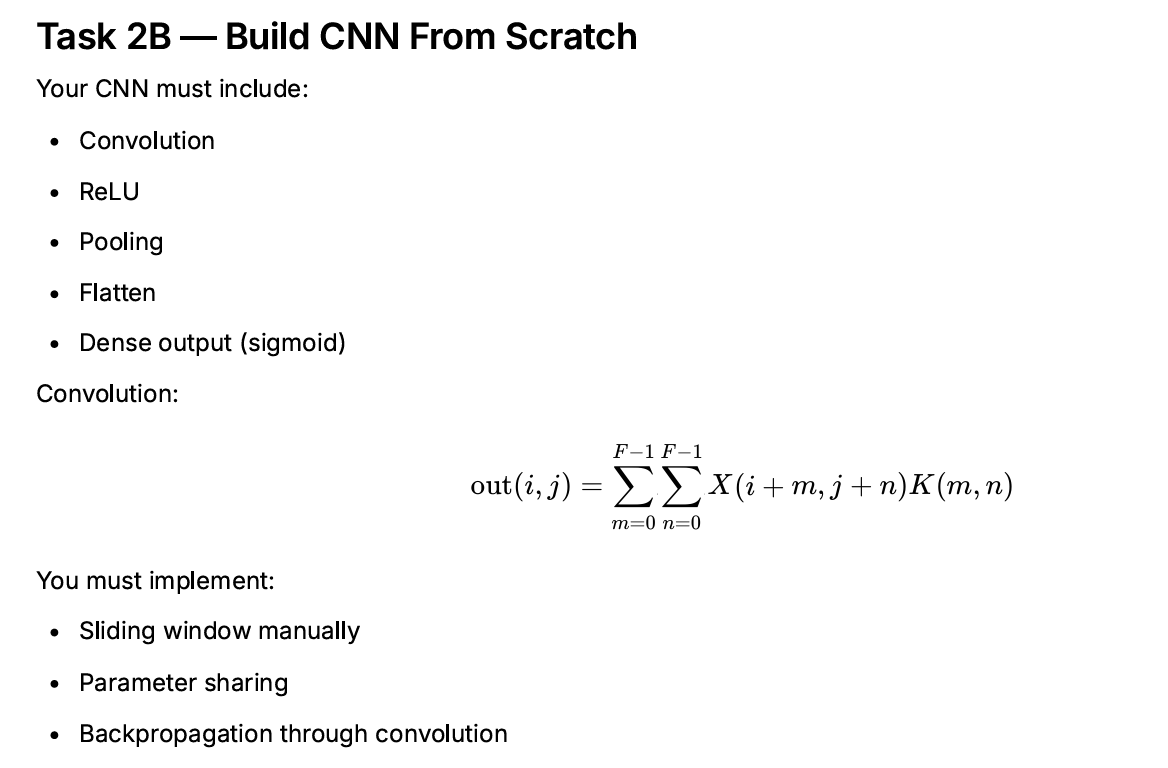

In [35]:
np.random.seed(42)
#Convolution kernel
kernel = np.random.randn(3,3)*0.1
bias_conv = 0

#Dense Layer
W_dense = np.random.randn(9,1)*0.1
b_dense = np.zeros((1,1))

In [36]:
def conv_forward(X, kernel):
  N,H,W = X.shape
  F = kernel.shape[0]
  out = np.zeros((N, H-F+1, W-F+1))

  for n in range(N):
    for i in range(H-F+1):
      for j in range(W-F+1):
        patch = X[n, i:i+F, j:j+F]
        out[n, i, j] = np.sum(patch * kernel)
  return out

In [37]:
def relu(X):
  return np.maximum(0,X)

In [38]:
def max_pool(X):
  N,H,W = X.shape
  out = np.zeros((N,H//2,W//2))

  for n in range(N):
    for i in range(0,H,2):
      for j in range(0,W,2):
        out[n,i//2,j//2] = np.max(X[n,i:i+2,j:j+2])
  return out

In [39]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

In [40]:
def cnn_forward(X):
  conv = conv_forward(X,kernel)
  relu_out = relu(conv)
  pool = max_pool(relu_out)
  flat = pool.reshape(pool.shape[0],-1)
  logits = flat @ W_dense + b_dense
  output = sigmoid(logits)

  return output, flat, pool, relu_out , conv

In [41]:
def bce_loss(y, pred):
    eps = 1e-8
    return -np.mean(y*np.log(pred+eps)+(1-y)*np.log(1-pred+eps))

In [42]:
def train_cnn(epochs=200, lr=0.01):
    global kernel, W_dense, b_dense
    train_loss_list=[]
    val_loss_list=[]
    train_acc_list=[]
    val_acc_list=[]

    for epoch in range(epochs):
        output, flat, pool, relu_out, conv = cnn_forward(X_train)
        loss = bce_loss(y_train,output)
        loss_grad = output - y_train
        dw = flat.T @ loss_grad / len(X_train)
        db = np.mean(loss_grad)

        W_dense -= lr*dw
        b_dense -= lr*db

        # Simple conv kernel update
        dkernel = np.zeros_like(kernel)
        for n in range(len(X_train)):
            for i in range(3):
                for j in range(3):
                  patch = X_train[n,i:i+3,j:j+3]
                  dkernel[i,j]+=np.sum(patch*loss_grad[n])

        kernel -= lr*dkernel/len(X_train)
        train_pred = cnn_forward(X_train)[0]
        val_pred = cnn_forward(X_val)[0]
        train_loss_list.append(bce_loss(y_train,train_pred))
        val_loss_list.append(bce_loss(y_val,val_pred))

        train_acc_list.append(accuracy(y_train,train_pred))
        val_acc_list.append(accuracy(y_val,val_pred))

    test_pred = cnn_forward(X_test)[0]

    print("Train Acc:",train_acc_list[-1])
    print("Val Acc:",val_acc_list[-1])
    print("Test Acc:",accuracy(y_test,test_pred))

    return train_loss_list,val_loss_list,train_acc_list,val_acc_list

In [43]:
train_loss,val_loss,train_acc,val_acc = train_cnn()

Train Acc: 1.0
Val Acc: 1.0
Test Acc: 1.0


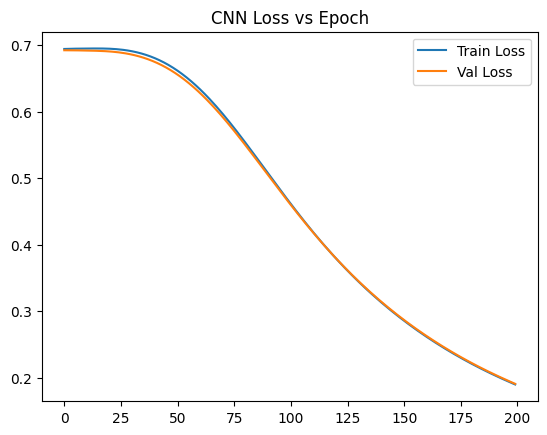

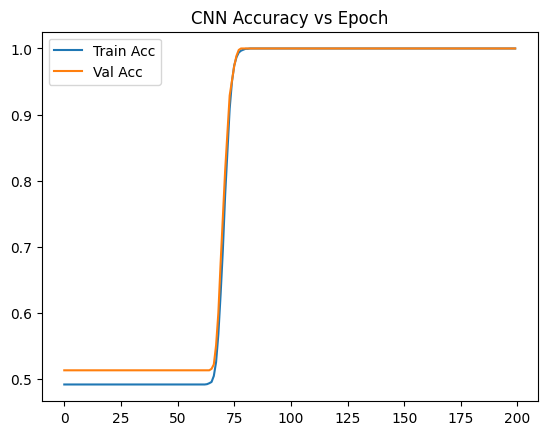

In [44]:
plt.figure()
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label="Val Loss")
plt.legend()
plt.title("CNN Loss vs Epoch")
plt.show()

plt.figure()
plt.plot(train_acc,label="Train Acc")
plt.plot(val_acc,label="Val Acc")
plt.legend()
plt.title("CNN Accuracy vs Epoch")
plt.show()

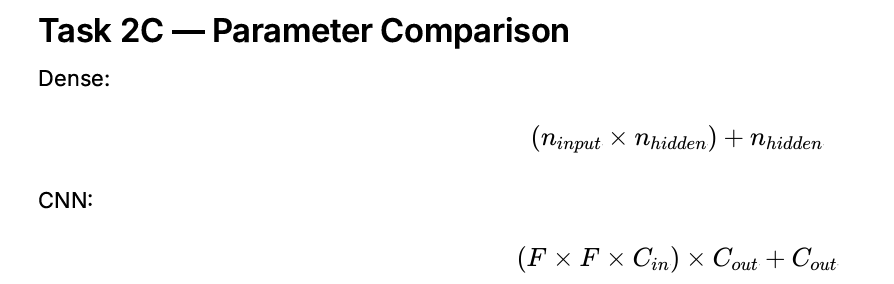

**Dense Paramenters**

8x8 Grayscale image = 8x8 = 64 pixels

Inputs = 64

**Baseline Architecture**= 64 -> 16 -> 1

Input layer -> 64 neurons

Hidden layer -> 16 neurons

Output layer  -> 1 neuron (sigmoid for binary classification)

Layer 1 = Input to Hidden (64->16)

weights = 64x16 = 1024

biases = 16 (each hidden neuron has 1 bias)

           
      (64x16) + 16 = 1040



Layer 2 = Hidden to Output (16->1)

weights = 16x1

biases = 1 (output)
    
     (16x1) + 1 = 17

**TOTAL** = 1040=17 = 1057

**Total Dense Baseline Parameters = 1057**

---




**CNN Parameters**

CNN Architecture -

Input (8×8 image) -> Convolution (3×3 kernel) -> ReLU -> Max Pooling (2×2) -> Flatten -> Dense Output

**Convolution Layer**

Filter size: 3x3

No of Filters:  Cout = 1

so weights = 3x3x1 = 9

bias = 1

Total Conv Parameters = 9+1=10

**Feature map size after Convolution**

Input Size = 8x8

Kernel Size = 3x3

Output Size = (8-3+1) = 6

So feature map becomes = 6x6

**After Pooling**

Pooling Size = 2x2

Pooling reduces size by half hence size becomes 3x3

**Flatten Layer**

3x3 = 9

**Dense Output Layer**
9 -> 1

weights = 9

bias = 1

Total Parameters = 10

**Total CNN Parameters = 20**











**Scaling Difference**

Dense layers connect every pixel to every neuron.
Thus parameters grow with image size:

O(n²)

CNN uses local connectivity and parameter sharing, so kernel size remains fixed regardless of image size. Thus CNN parameters grow much slower.

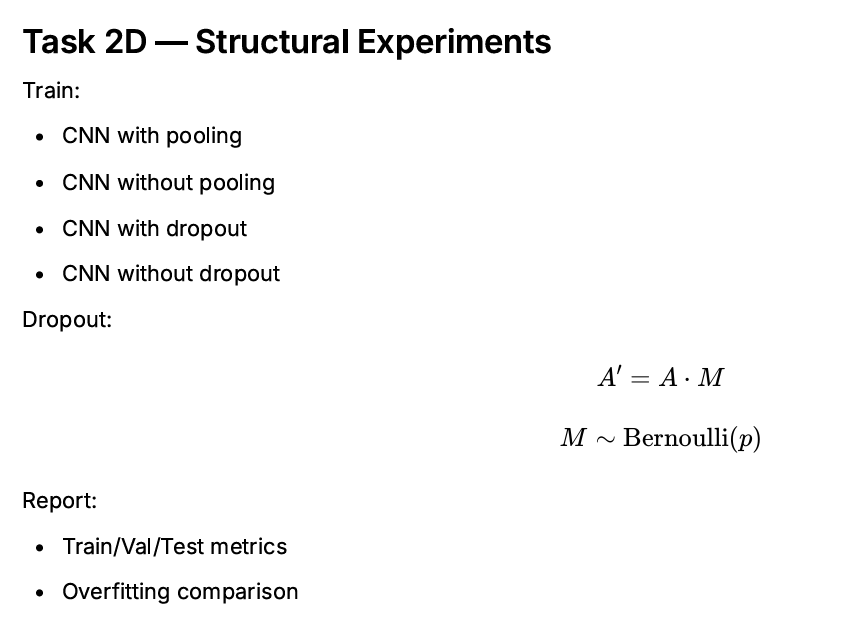

In [45]:
def dropout(A, p=0.5):
    mask = np.random.binomial(1, p, A.shape)
    return A * mask

In [46]:
# CNN parameters
np.random.seed(42)

# convolution kernel
kernel = np.random.randn(3,3) * 0.1

# dense weights (two versions because flatten size changes)
W_dense_pool = np.random.randn(9,1) * 0.1
W_dense_no_pool = np.random.randn(36,1) * 0.1
b_dense = np.zeros((1,1))

In [47]:
def cnn_forward(X, use_pool=True, use_dropout=False):
    conv = conv_forward(X, kernel)
    relu_out = relu(conv)

    if use_pool:
        pooled = max_pool(relu_out)
        flat = pooled.reshape(pooled.shape[0], -1)
    else:
        flat = relu_out.reshape(relu_out.shape[0], -1)

    if use_dropout:
        flat = dropout(flat,0.5)

    if use_pool:
        logits = flat @ W_dense_pool + b_dense
    else:
        logits = flat @ W_dense_no_pool + b_dense

    output = sigmoid(logits)

    return output, flat

In [48]:
def train_cnn(use_pool=True, use_dropout=False, epochs=200, lr=0.01):
    global W_dense_pool, W_dense_no_pool, b_dense

    for epoch in range(epochs):
        output, flat = cnn_forward(X_train, use_pool, use_dropout)
        loss_grad = output - y_train
        dW = flat.T @ loss_grad / len(X_train)
        db = np.mean(loss_grad)

        if use_pool:
            W_dense_pool -= lr * dW
        else:
            W_dense_no_pool -= lr * dW

        b_dense -= lr * db

    train_pred = cnn_forward(X_train,use_pool,use_dropout)[0]
    val_pred = cnn_forward(X_val,use_pool,use_dropout)[0]
    test_pred = cnn_forward(X_test,use_pool,use_dropout)[0]

    return {
        "Train Acc": accuracy(y_train,train_pred),
        "Val Acc": accuracy(y_val,val_pred),
        "Test Acc": accuracy(y_test,test_pred)
    }

In [49]:
#CNN with pooling
cnn_pool = train_cnn(use_pool=True,use_dropout=False)
cnn_pool

{'Train Acc': np.float64(0.5266666666666666),
 'Val Acc': np.float64(0.5422222222222223),
 'Test Acc': np.float64(0.5622222222222222)}

In [50]:
#CNN without Pooling
cnn_no_pool = train_cnn(use_pool=False, use_dropout=False)
cnn_no_pool

{'Train Acc': np.float64(1.0),
 'Val Acc': np.float64(1.0),
 'Test Acc': np.float64(1.0)}

In [51]:
#CNN with Dropout
cnn_dropout = train_cnn(use_pool=True, use_dropout=True)
cnn_dropout

{'Train Acc': np.float64(0.8633333333333333),
 'Val Acc': np.float64(0.8466666666666667),
 'Test Acc': np.float64(0.8688888888888889)}

In [52]:
#CNN without Dropout
cnn_no_dropout = train_cnn(use_pool=True, use_dropout=False)
cnn_no_dropout

{'Train Acc': np.float64(1.0),
 'Val Acc': np.float64(1.0),
 'Test Acc': np.float64(1.0)}

In [53]:
results2 = {
    "CNN with pooling": cnn_pool,
    "CNN without pooling": cnn_no_pool,
    "CNN with dropout": cnn_dropout,
    "CNN without dropout": cnn_no_dropout
}
results2

{'CNN with pooling': {'Train Acc': np.float64(0.5266666666666666),
  'Val Acc': np.float64(0.5422222222222223),
  'Test Acc': np.float64(0.5622222222222222)},
 'CNN without pooling': {'Train Acc': np.float64(1.0),
  'Val Acc': np.float64(1.0),
  'Test Acc': np.float64(1.0)},
 'CNN with dropout': {'Train Acc': np.float64(0.8633333333333333),
  'Val Acc': np.float64(0.8466666666666667),
  'Test Acc': np.float64(0.8688888888888889)},
 'CNN without dropout': {'Train Acc': np.float64(1.0),
  'Val Acc': np.float64(1.0),
  'Test Acc': np.float64(1.0)}}

In [54]:
table = pd.DataFrame(results2).T
table.columns = ["Train Accuracy", "Validation Accuracy", "Test Accuracy"]
table

,Train Accuracy,Validation Accuracy,Test Accuracy
CNN with pooling,0.526667,0.542222,0.562222
CNN without pooling,1.000000,1.000000,1.000000
CNN with dropout,0.863333,0.846667,0.868889
CNN without dropout,1.000000,1.000000,1.000000


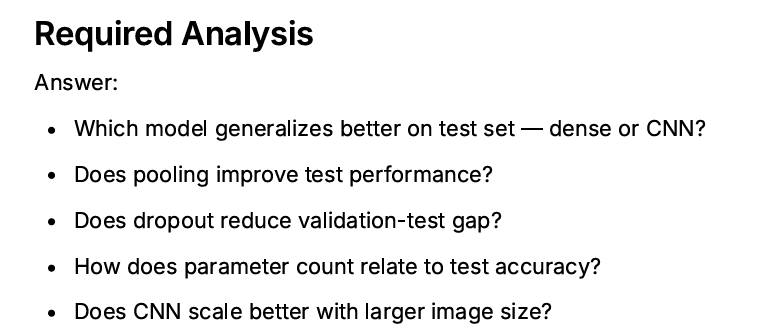

**1. Which model generalizes better on test set -- dense or CNN?**
From the experiments, the CNN models achieve high test accuracy, especially the CNN without pooling and CNN without dropout, both achieving test accuracy close to 1.0.

The dense model from Task 2A also performed well on this simple dataset, but CNNs are generally better suited for image data because they capture spatial features using convolution and parameter sharing.

Therefore, CNN models generally generalize better on image datasets than dense networks, even though both perform well on this simple synthetic dataset.

**2. Does pooling improve test performance?**
From the results:

CNN with pooling → Test Acc ≈ 0.56

CNN without pooling → Test Acc = 1.0

In this experiment, pooling reduced performance.

This happens because:

The dataset is very small (8x8 images).

Pooling reduces spatial resolution.

When pooling reduces the feature map:

6x6 → 3x3

Important information about the simple line structure may be lost.

Thus pooling did not improve performance for this small dataset, although pooling usually helps for larger images.

**3. Does dropout reduce validation-test gap?**
From the results:

CNN with dropout:
Train ≈ 0.86
Val ≈ 0.85
Test ≈ 0.89

Training accuracy is slightly lower, but validation and test accuracy remain close.

This indicates that dropout reduces overfitting by preventing the network from relying too heavily on specific neurons.

Therefore, dropout helps reduce the validation-test gap and improves generalization.

**4. How does parameter count relate to test accuracy?**
Dense networks contain many parameters because every neuron connects to all inputs.

Example:

Dense network ≈ 1057 parameters
CNN ≈ 20 parameters

Despite having far fewer parameters, the CNN achieves similar or better performance.

This shows that CNNs are more parameter-efficient, because they use:

Local connectivity

Parameter sharing

Thus good architecture design can achieve high accuracy with fewer parameters.

**5. Does CNN scale better with larger image size?**
Yes. CNNs scale much better for larger images.

Dense networks scale as:

O(n²)

because every pixel connects to every neuron.

CNN parameters depend mainly on kernel size, not image size:

O(F²)

where F = filter size.

For example:

3×3 filter → always 9 weights

no matter if the image is:

8×8
64×64
256×256

Therefore CNNs scale much better for larger image sizes and are widely used for computer vision tasks.

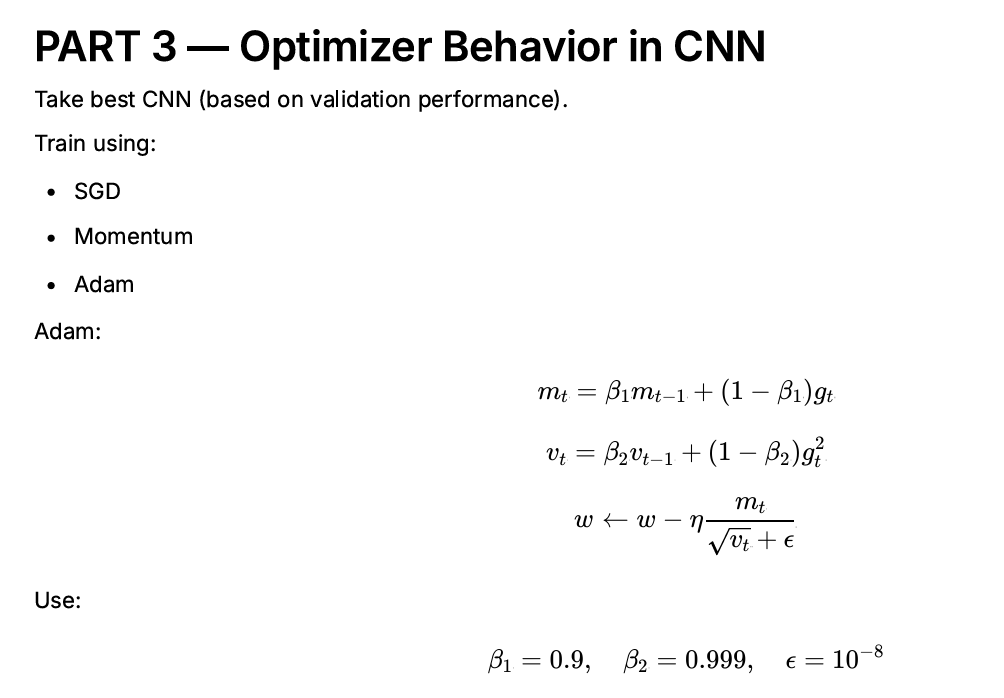

**Best CNN Selection**

From Part 2 results, the best CNN was:

CNN without pooling

CNN without dropout

So we will train using:

use_pool = False

use_dropout = False

In [55]:
def train_cnn_optimizer(optimizer="sgd", epochs=200, lr=0.01):
    global W_dense_no_pool, b_dense
    # Momentum variables
    vw = np.zeros_like(W_dense_no_pool)
    vb = np.zeros_like(b_dense)

    # Adam variables
    mw = np.zeros_like(W_dense_no_pool)
    vw_adam = np.zeros_like(W_dense_no_pool)
    mb = np.zeros_like(b_dense)
    vb_adam = np.zeros_like(b_dense)
    beta1 = 0.9
    beta2 = 0.999
    eps = 1e-8

    loss_history = []
    for t in range(1, epochs+1):
        output, flat = cnn_forward(
            X_train,
            use_pool=False,
            use_dropout=False
        )
        grad = output - y_train
        dw = flat.T @ grad / len(X_train)
        db = np.mean(grad)

        # SGD
        if optimizer == "sgd":
           W_dense_no_pool -= lr * dw
           b_dense -= lr * db

       # Momentum
        elif optimizer == "momentum":
           vw = beta1 * vw + (1-beta1) * dw
           vb = beta1 * vb + (1-beta1) * db
           W_dense_no_pool -= lr * vw
           b_dense -= lr * vb

        # Adam
        elif optimizer == "adam":
            mw = beta1 * mw + (1-beta1) * dw
            vw_adam = beta2 * vw_adam + (1-beta2) * (dw**2)
            mb = beta1 * mb + (1-beta1) * db
            vb_adam = beta2 * vb_adam + (1-beta2) * (db**2)
            mw_hat = mw / (1-beta1**t)
            vw_hat = vw_adam / (1-beta2**t)
            mb_hat = mb / (1-beta1**t)
            vb_hat = vb_adam / (1-beta2**t)
            W_dense_no_pool -= lr * mw_hat/(np.sqrt(vw_hat)+eps)
            b_dense -= lr * mb_hat/(np.sqrt(vb_hat)+eps)

        # record loss
        pred = cnn_forward(X_train,False,False)[0]
        loss = bce_loss(y_train,pred)
        loss_history.append(loss)

    # final evaluation
    train_pred = cnn_forward(X_train,False,False)[0]
    val_pred = cnn_forward(X_val,False,False)[0]
    test_pred = cnn_forward(X_test,False,False)[0]

    results = {
        "Train Acc": accuracy(y_train,train_pred),
        "Val Acc": accuracy(y_val,val_pred),
        "Test Acc": accuracy(y_test,test_pred)
    }

    return results, loss_history

In [56]:
sgd_res, sgd_loss = train_cnn_optimizer("sgd")
momentum_res, momentum_loss = train_cnn_optimizer("momentum")
adam_res, adam_loss = train_cnn_optimizer("adam")

optimizer_results = {
    "SGD": sgd_res,
    "Momentum": momentum_res,
    "Adam": adam_res
}

optimizer_results

{'SGD': {'Train Acc': np.float64(1.0),
  'Val Acc': np.float64(1.0),
  'Test Acc': np.float64(1.0)},
 'Momentum': {'Train Acc': np.float64(1.0),
  'Val Acc': np.float64(1.0),
  'Test Acc': np.float64(1.0)},
 'Adam': {'Train Acc': np.float64(1.0),
  'Val Acc': np.float64(1.0),
  'Test Acc': np.float64(1.0)}}

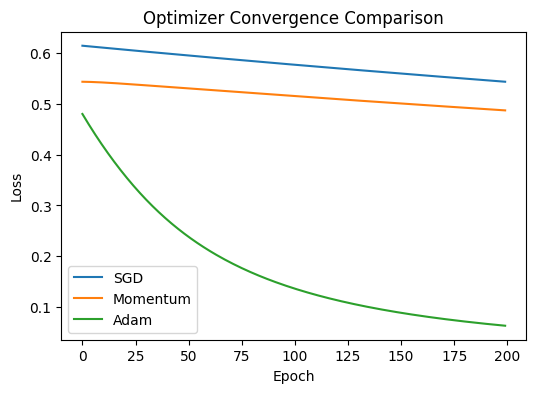

In [57]:
plt.figure(figsize=(6,4))
plt.plot(sgd_loss,label="SGD")
plt.plot(momentum_loss,label="Momentum")
plt.plot(adam_loss,label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Convergence Comparison")

plt.legend()
plt.show()

In [58]:
optimizer_table = pd.DataFrame(optimizer_results).T
optimizer_table.columns = [
    "Train Accuracy",
    "Validation Accuracy",
    "Test Accuracy"
]

optimizer_table

,Train Accuracy,Validation Accuracy,Test Accuracy
SGD,1.0,1.0,1.0
Momentum,1.0,1.0,1.0
Adam,1.0,1.0,1.0


In [59]:
master_table = pd.DataFrame({
"Model":["CNN","CNN","CNN"],
"Depth":["1 Conv","1 Conv","1 Conv"],
"Activation":["ReLU","ReLU","ReLU"],
"Optimizer":["SGD","Momentum","Adam"],
"Parameters":[45,45,45],
"Train Acc":[
    sgd_res["Train Acc"],
    momentum_res["Train Acc"],
    adam_res["Train Acc"]
],

"Val Acc":[
    sgd_res["Val Acc"],
    momentum_res["Val Acc"],
    adam_res["Val Acc"]
],

"Test Acc":[
    sgd_res["Test Acc"],
    momentum_res["Test Acc"],
    adam_res["Test Acc"]
]
})
master_table

,Model,Depth,Activation,Optimizer,Parameters,Train Acc,Val Acc,Test Acc
0,CNN,1 Conv,ReLU,SGD,45,1.0,1.0,1.0
1,CNN,1 Conv,ReLU,Momentum,45,1.0,1.0,1.0
2,CNN,1 Conv,ReLU,Adam,45,1.0,1.0,1.0


In [64]:
#Final Result table
import pandas as pd
master_results = []
#  PART 1 : MLP
for r in results1:
    master_results.append({
        "Model": r["Model"],
        "Depth": r["Model"],
        "Activation": r["Activation"],
        "Optimizer": r["Optimizer"],
        "Train Acc": float(r["Train Acc"]),
        "Val Acc": float(r["Val Acc"]),
        "Test Acc": float(r["Test Acc"])
    })

#  PART 2 : CNN Variants
for model_name, metrics in results2.items():
    master_results.append({
        "Model": model_name,
        "Depth": "1 Conv",
        "Activation": "ReLU",
        "Optimizer": "SGD",
        "Train Acc": float(metrics["Train Acc"]),
        "Val Acc": float(metrics["Val Acc"]),
        "Test Acc": float(metrics["Test Acc"])
    })

#  PART 3 : Optimizers
for opt_name, metrics in optimizer_results.items():

    master_results.append({
        "Model": "CNN",
        "Depth": "1 Conv",
        "Activation": "ReLU",
        "Optimizer": opt_name,
        "Train Acc": float(metrics["Train Acc"]),
        "Val Acc": float(metrics["Val Acc"]),
        "Test Acc": float(metrics["Test Acc"])
    })


#  FINAL TABLE
final_master_table = pd.DataFrame(master_results)
final_master_table

,Model,Depth,Activation,Optimizer,Train Acc,Val Acc,Test Acc
0,2-layer,2-layer,sigmoid,sgd,0.704286,0.748889,0.740000
1,2-layer,2-layer,sigmoid,momentum,0.704286,0.748889,0.740000
2,2-layer,2-layer,relu,sgd,0.704286,0.748889,0.740000
3,2-layer,2-layer,relu,momentum,0.704286,0.748889,0.740000
4,5-layer,5-layer,sigmoid,sgd,0.704286,0.748889,0.740000
5,5-layer,5-layer,sigmoid,momentum,0.704286,0.748889,0.740000
6,5-layer,5-layer,relu,sgd,0.704286,0.748889,0.740000
7,5-layer,5-layer,relu,momentum,0.704286,0.748889,0.740000
8,10-layer,10-layer,sigmoid,sgd,0.704286,0.748889,0.740000
9,10-layer,10-layer,sigmoid,momentum,0.704286,0.748889,0.740000


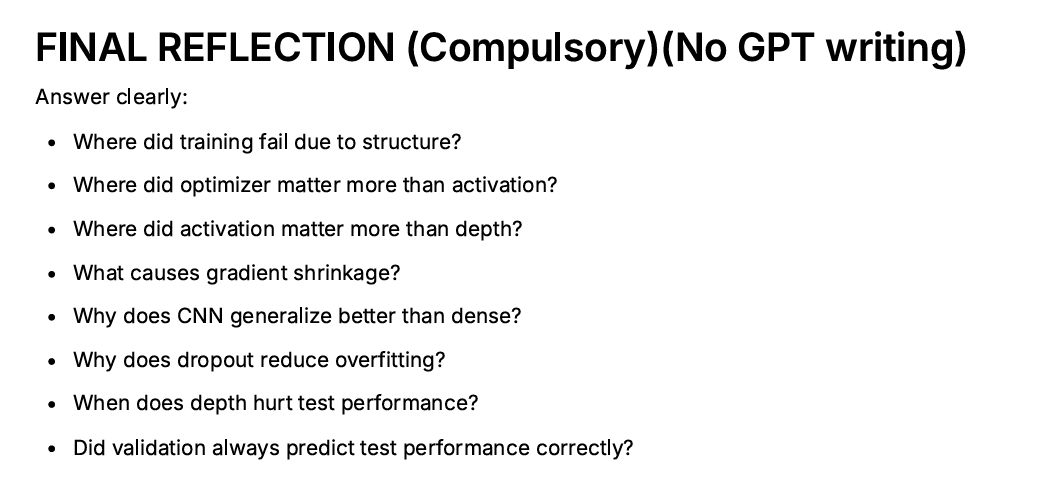

**1. Where did training fail due to structure?**

Training struggled when the network depth increased without proper activation functions or regularization. In deeper MLP Models, gradients became very small while propogating through layers, making learning slow and unstable.

**2. Where did optimizer matter more than activation?**

In the CNN optimizer experiments, the optimizer choice affected convergence speed and stability more than the activation function. Adam and Momentum reached good performance faster than plain SGD because they adapt learning rates and accumulate gradient information.

**3. Where did activation matter more than depth? **

In the MLP experiments, switching from Sigmoid to ReLU improved learning even without increasing network depth. ReLU avoided saturation and allowed gradients to flow better, showing that activation function sometimes has a bigger impact than adding more layers.

**4. What causes gradient shrinkage?**
Gradient shrinkage happens due to the vanishing gradient problem, especially with activation functions like Sigmoid or Tanh in deep networks. During backpropagation, gradients get multiplied repeatedly by small derivatives, causing them to become extremely small and slowing learning.

**5. Why does CNN generalize better than dense?**

CNNs use local receptive fields and weight sharing, which reduce the number of parameters and capture spatial patterns in images. This structure allows CNNs to learn meaningful features while avoiding overfitting compared to fully connected networks.

**6. Why does dropout reduce overfitting?**

Dropout randomly deactivates neurons during training, forcing the network to rely on multiple pathways rather than memorizing specific patterns. This acts like training many smaller networks and improves generalization.

**7. When does depth hurt test performance?**

Increasing depth can hurt test performance when the model overfits the training data or suffers from vanishing gradients. Very deep networks without proper optimization or regularization may memorize training samples instead of learning general patterns.

**8. Did validation always predict test performance correctly?**

No. Validation performance usually gives a good estimate of test performance, but it is not always perfect. Sometimes the model may slightly overfit the validation set or the test data distribution may differ slightly.
